# Whakaari Cause–Trigger Analysis

This notebook applies the Cause–Trigger analysis to the Whakaari case. HMML is the main parent-discovery backend; PCMCI and PCMCI+ provide comparisons. PCMCI+ also screens eligible directed same-hour links tau=0 as trigger candidates while using lagged parents to construct \(V\).

The main analysis uses maximum lag orders \(d=1,...,12\) for every backend. Minimum-\(I_2\) values 36, 48, 60 and 72 h assess partition stability.

Minimum-\(I_2\) settings that generate the same split are not independent replications. The backend × lag grid is therefore run once per unique partition, with all corresponding minimum-\(I_2\) values recorded as metadata.

The target is the positive tremor anomaly. The classification F-test uses alpha=0.05. BH-adjusted p-values are reported separately and do not change which pairs the algorithm returns. The hierarchical F-test and Newey–West tests at 6, 12, and 24 h are sensitivity checks.

## Configuration

In [1]:
from pathlib import Path
import sys
import warnings

import pandas as pd

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cause_trigger_reporting import (
    automatic_lag_outcome_table,
    backend_split_summary,
    export_results_csvs,
    mean_shift_role_table,
    interaction_sensitivity_summary,
    bh_summary,
    pair_split_lag_summary,
    plot_effect_with_splits,
    plot_mean_shift_roles,
    plot_interaction_sensitivity_heatmap,
    plot_pair_stability_heatmap,
    run_unique_split_grid,
    show_table,
    split_display_table,
    warning_pattern_summary,
    warning_summary,
)
from cause_trigger_workflow import (
    COMPACT_RUN_SPECS,
    prepare_case_analysis,
    reference_parameter_table,
    run_one,
)

from cause_trigger_cases import WHAKAARI_CASE

CASE = WHAKAARI_CASE
EFFECT = CASE.effect
VARIABLE_LABELS = CASE.variable_labels

FIGURE_LABELS = {
    **VARIABLE_LABELS,
    "spectral_log_ratio_4p5_8_over_8_16_scaled": "Spectral contrast",
    "hydro_2_5_scaled": "Hydrothermal RMS",
    "GNSS_deformation_rate_scaled": "GNSS change",
    "rainfall_mm_scaled": "Rainfall",
    EFFECT: "Tremor anomaly",
}

DATA_PATH = PROJECT_ROOT / "data/whakaari/whakaari_dataset.csv"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

SAVE_RESULTS = True
SHOW_FULL_GRID = False
SHOW_SCALING_REPORT = False

EVENT_TIME = pd.Timestamp("2019-12-09 01:11:00", tz="UTC")
EVENT_LABEL = "Whakaari eruption time"

CASE_PRE_DAYS = 7
CASE_POST_DAYS = 4
REFERENCE_DAYS = 14
REFERENCE_MIN_COVERAGE = 0.90

MIN_I1_LENGTH = 72
MIN_I2_GRID = (36, 48, 60, 72)
LAG_GRID = tuple(range(1, 13))

ALPHA = 0.05
PCMCI_PC_ALPHA = 0.2
PCMCI_PLUS_PC_ALPHA = 0.01
PCMCI_ALPHA_LEVEL = 0.05
PCMCI_FDR_METHOD = "fdr_bh"
COND_IND_TEST = "robust_parcorr"
NEWEY_WEST_LAGS = (6, 12, 24)

## Data preparation and partition stability

The causal interval contains 7 days before and 4 days after the contextual event hour. The preceding 14-day reference interval supplies transformation and decision-scale parameters; it is not part of \(I_1\) or \(I_2\). The mean-shift figure shows the screening and ranking scores, not physical effect sizes or causal strengths.

Item,Value
Dataset coverage,2019-10-01 12:00:00+00:00 to 2019-12-16 23:00:00+00:00 (1826 retained hourly rows)
Causal-analysis interval,"[2019-12-02 01:00:00+00:00, 2019-12-13 01:00:00+00:00) (264 h; 7 d before and 4 d after the event hour)"
Reference interval,"[2019-11-18 01:00:00+00:00, 2019-12-02 01:00:00+00:00); 327/336 h (97.3% coverage)"
Whakaari eruption time,2019-12-09 01:11:00+00:00
Effect maximum,2019-12-09 01:00:00+00:00 (-1 days +23:49:00 from event)
Minimum interval design,"I1 >= 72 h; minimum-I2 grid = (36, 48, 60, 72) h"
Maximum-lag-order design,"d = 1-12 h for HMML, PCMCI, and PCMCI+"
PCMCI extension settings,PCMCI pc_alpha=0.2; PCMCI+ graph pc_alpha=0.01; lagged-link alpha=0.05; lagged-link FDR=fdr_bh; PCMCI+ tau=0 links exploratory without BH adjustment; conditional-independence test=robust_parcorr
Interaction sensitivity,"Classification F-test; hierarchical F-test and Newey--West tests at truncation lags (6, 12, 24) h"
Unique response partitions,3 unique partition(s) from 4 minimum-I2 settings


Minimum I2 (h),Partition,Split time,I1 (h),I2 (h),Split score,Boundary split,Offset from event
36,S3,2019-12-10 19:00:00+00:00,210,54,2.443198,False,1 days 17:49:00
48,S3,2019-12-10 19:00:00+00:00,210,54,2.443198,False,1 days 17:49:00
60,S2,2019-12-10 13:00:00+00:00,204,60,2.281526,True,1 days 11:49:00
72,S1,2019-12-10 01:00:00+00:00,192,72,2.043327,True,0 days 23:49:00


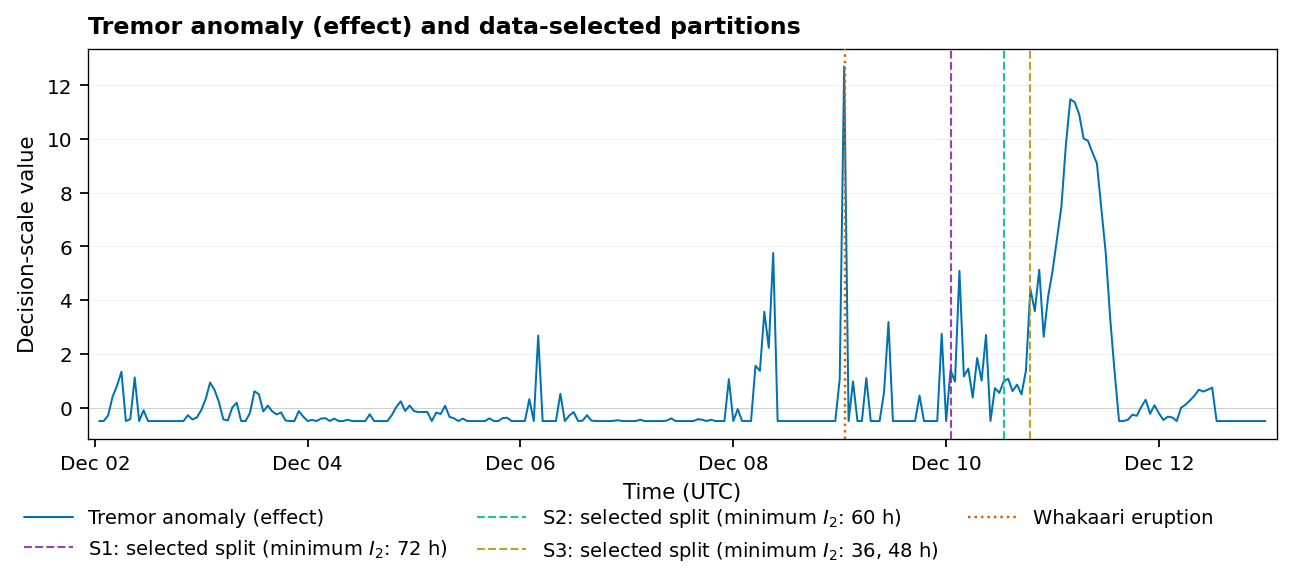

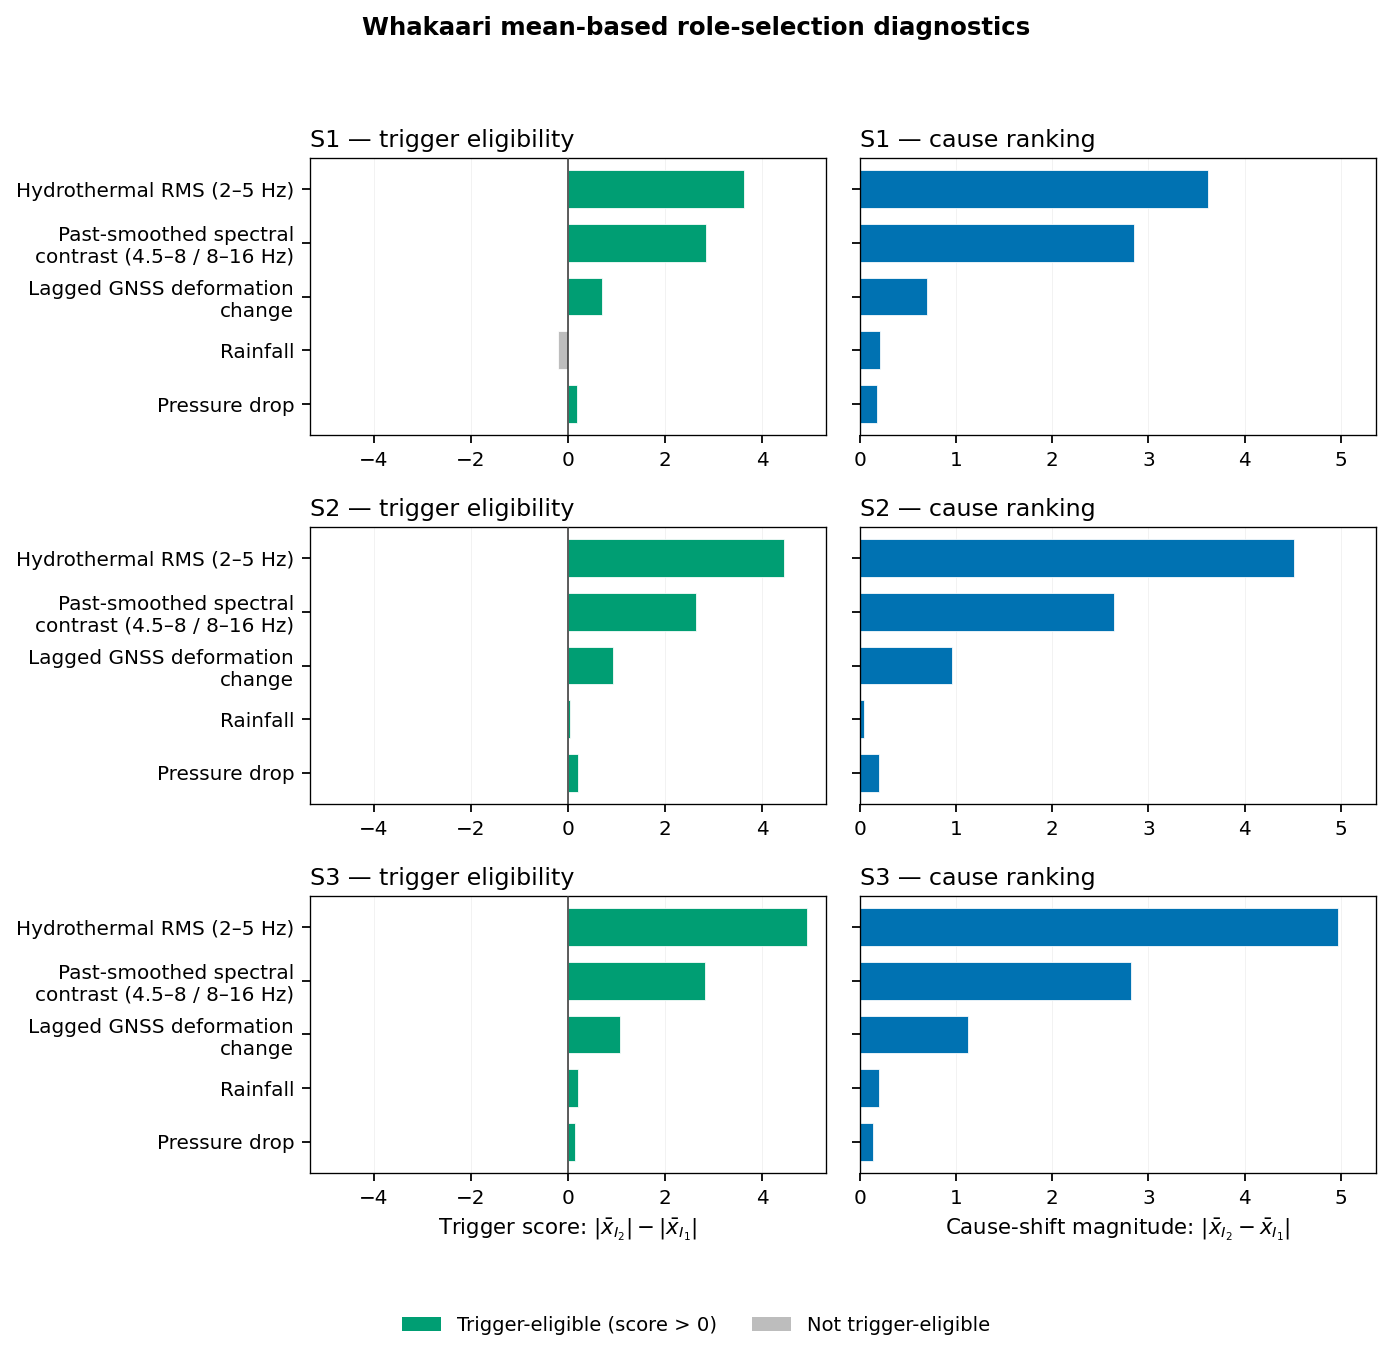

(<Figure size 1408x1360 with 6 Axes>,
 array([[<Axes: title={'left': 'S1 — trigger eligibility'}>,
         <Axes: title={'left': 'S1 — cause ranking'}>],
        [<Axes: title={'left': 'S2 — trigger eligibility'}>,
         <Axes: title={'left': 'S2 — cause ranking'}>],
        [<Axes: title={'left': 'S3 — trigger eligibility'}, xlabel='Trigger score: $|\\bar{x}_{I_2}|-|\\bar{x}_{I_1}|$'>,
         <Axes: title={'left': 'S3 — cause ranking'}, xlabel='Cause-shift magnitude: $|\\bar{x}_{I_2}-\\bar{x}_{I_1}|$'>]],
       dtype=object),
 [WindowsPath('c:/Users/cescedes/Desktop/Distinguishing Causes and Triggers in Volcanic and Seismic Processes/figures/whakaari_mean_shift_roles.pdf'),
  WindowsPath('c:/Users/cescedes/Desktop/Distinguishing Causes and Triggers in Volcanic and Seismic Processes/figures/whakaari_mean_shift_roles.png')])

In [2]:
analysis = prepare_case_analysis(
    data_path=DATA_PATH,
    case=CASE,
    event_time=EVENT_TIME,
    event_label=EVENT_LABEL,
    case_pre_days=CASE_PRE_DAYS,
    case_post_days=CASE_POST_DAYS,
    reference_days=REFERENCE_DAYS,
    reference_min_coverage=REFERENCE_MIN_COVERAGE,
    min_I1_length=MIN_I1_LENGTH,
    min_I2_values=MIN_I2_GRID,
    lag_grid=LAG_GRID,
    alpha=ALPHA,
    pcmci_pc_alpha=PCMCI_PC_ALPHA,
    pcmci_plus_pc_alpha=PCMCI_PLUS_PC_ALPHA,
    pcmci_alpha_level=PCMCI_ALPHA_LEVEL,
    pcmci_fdr_method=PCMCI_FDR_METHOD,
    cond_ind_test=COND_IND_TEST,
    newey_west_lags=NEWEY_WEST_LAGS,
)

show_table(analysis.design_summary, "Final analysis design and timing")
show_table(
    split_display_table(analysis.split_summary),
    "Response transition across minimum-I2 settings",
)

if SHOW_SCALING_REPORT:
    show_table(
        analysis.scaling_report.reset_index(names="Variable"),
        "Transformation and scaling audit",
    )

plot_effect_with_splits(
    analysis.X_decision,
    EFFECT,
    analysis.split_summary,
    event_time=EVENT_TIME,
    effect_label=VARIABLE_LABELS[EFFECT],
    event_label="Whakaari eruption",
    filename="whakaari_effect_splits",
    save_dir=FIGURES_DIR,
)

role_shift_table = mean_shift_role_table(
    analysis.X_decision,
    EFFECT,
    analysis.split_summary,
    variable_labels=VARIABLE_LABELS,
)
plot_mean_shift_roles(
    role_shift_table,
    title="Whakaari mean-based role-selection diagnostics",
    filename="whakaari_mean_shift_roles",
    save_dir=FIGURES_DIR,
)

## Cause–Trigger analysis over unique partitions

A maximum order \(d=k\) permits lags from 1 through \(k\) hours. Results are interpreted through recurrence across adjacent orders, partitions, and backends, not by selecting the smallest p-value. The stability heatmap distinguishes non-selection, non-evaluability, failure to reject, a pair returned by the F-test, and a result that remains significant after BH adjustment.

For each evaluable candidate, the sensitivity model is $$y_t=\gamma_0+\gamma_1V_{s,t}+\gamma_sx_{s,t}+\gamma_2V_{s,t}x_{s,t}+\varepsilon_t.$$ The hierarchical F-test and Newey–West tests of \(H_0:\gamma_2=0\) use truncation lags of 6, 12, and 24 h. Each test family receives its own case-wide BH adjustment. These tests assess sensitivity to the trigger main effect and serial correlation; they do not change the returned pairs.

Partition,Minimum I2 values,Backend,Completed runs,Lags with post-transition parents,Lags with trigger candidates,Lags with evaluable F-tests,Lags returning a pair,Lags with τ=0 links,Runs with warnings,Result
S1,[72],HMML,12/12,9/12,8/12,8/12,8/12,0/12,12/12,Pair returned at 8 lag order(s)
S1,[72],PCMCI,12/12,9/12,9/12,2/12,1/12,0/12,0/12,Pair returned at 1 lag order(s)
S1,[72],PCMCI+ with eligible exploratory τ=0 triggers,12/12,6/12,6/12,0/12,0/12,2/12,0/12,Trigger candidates found; F-test not evaluable
S2,[60],HMML,12/12,9/12,9/12,8/12,7/12,0/12,12/12,Pair returned at 7 lag order(s)
S2,[60],PCMCI,12/12,5/12,5/12,1/12,1/12,0/12,0/12,Pair returned at 1 lag order(s)
S2,[60],PCMCI+ with eligible exploratory τ=0 triggers,12/12,2/12,2/12,0/12,0/12,0/12,0/12,Trigger candidates found; F-test not evaluable
S3,"[36, 48]",HMML,12/12,10/12,10/12,9/12,4/12,0/12,12/12,Pair returned at 4 lag order(s)
S3,"[36, 48]",PCMCI,12/12,5/12,5/12,1/12,1/12,0/12,0/12,Pair returned at 1 lag order(s)
S3,"[36, 48]",PCMCI+ with eligible exploratory τ=0 triggers,12/12,1/12,1/12,0/12,0/12,0/12,0/12,Trigger candidates found; F-test not evaluable


Backend,Trigger source,Cause,Trigger,Returned cells,After BH,Partition IDs,Partition count,Minimum I2 values,Lag orders,Lag-order count,Longest adjacent run
HMML,Lagged,Past-smoothed spectral contrast (4.5–8 / 8–16 Hz),Hydrothermal RMS (2–5 Hz),11/36,7/36,"['S1', 'S2', 'S3']",3/3,"[36, 48, 60, 72]","[5, 7, 8, 9, 10, 11, 12]",7/12,6
HMML,Lagged,Hydrothermal RMS (2–5 Hz),Past-smoothed spectral contrast (4.5–8 / 8–16 Hz),10/36,8/36,"['S1', 'S2', 'S3']",3/3,"[36, 48, 60, 72]","[4, 6, 7, 8, 9, 10, 11, 12]",8/12,7
HMML,Lagged,Hydrothermal RMS (2–5 Hz),Lagged GNSS deformation change,5/36,4/36,"['S2', 'S3']",2/3,"[36, 48, 60]","[6, 7, 9, 11]",4/12,2
PCMCI,Lagged,Lagged GNSS deformation change,Past-smoothed spectral contrast (4.5–8 / 8–16 Hz),3/36,2/36,"['S1', 'S2', 'S3']",3/3,"[36, 48, 60, 72]","[4, 7, 12]",3/12,1
HMML,Lagged,Hydrothermal RMS (2–5 Hz),Rainfall,3/36,1/36,"['S2', 'S3']",2/3,"[36, 48, 60]","[6, 7, 10]",3/12,2
PCMCI,Lagged,Past-smoothed spectral contrast (4.5–8 / 8–16 Hz),Lagged GNSS deformation change,2/36,0/36,"['S1', 'S2']",2/3,"[60, 72]","[7, 12]",2/12,1


Evaluable F-tests,F-test rejections,After BH
92,34,22


Test,Evaluable,p≤0.05,After BH,Classification overlap after BH,Same sign as classification model
Classification F-test,92,34,22,22/22,34/34
Hierarchical F-test,92,34,11,6/22,28/34
"Newey–West, L=6 h",92,30,23,7/22,28/34
"Newey–West, L=12 h",92,34,28,8/22,28/34
"Newey–West, L=24 h",92,47,36,11/22,28/34


Partition,Backend,Maximum lag orders,Runs,Warning count,Scope,Evaluable F-tests,F-test rejections,After BH,Execution errors,Warning pattern
S1,HMML,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",10,191,"complete backend run, including parent search",19,7,5,0,invalid value encountered in scalar divide
S1,HMML,"[11, 12]",2,41,"complete backend run, including parent search",7,3,2,0,"invalid value encountered in scalar divide; divide by zero encountered in scalar divide; Perfect separation or prediction detected, parameter may not be identified"
S2,HMML,"[1, 2, 3, 4, 5, 6, 7, 8]",8,182,"complete backend run, including parent search",17,9,6,0,invalid value encountered in scalar divide
S2,HMML,"[9, 10, 11, 12]",4,157,"complete backend run, including parent search",13,5,4,0,"invalid value encountered in scalar divide; divide by zero encountered in scalar divide; Perfect separation or prediction detected, parameter may not be identified"
S3,HMML,"[1, 2, 3, 4, 5, 6, 7]",7,177,"complete backend run, including parent search",14,3,3,0,invalid value encountered in scalar divide
S3,HMML,"[8, 9, 10, 11, 12]",5,215,"complete backend run, including parent search",14,2,0,0,"invalid value encountered in scalar divide; divide by zero encountered in scalar divide; Perfect separation or prediction detected, parameter may not be identified"


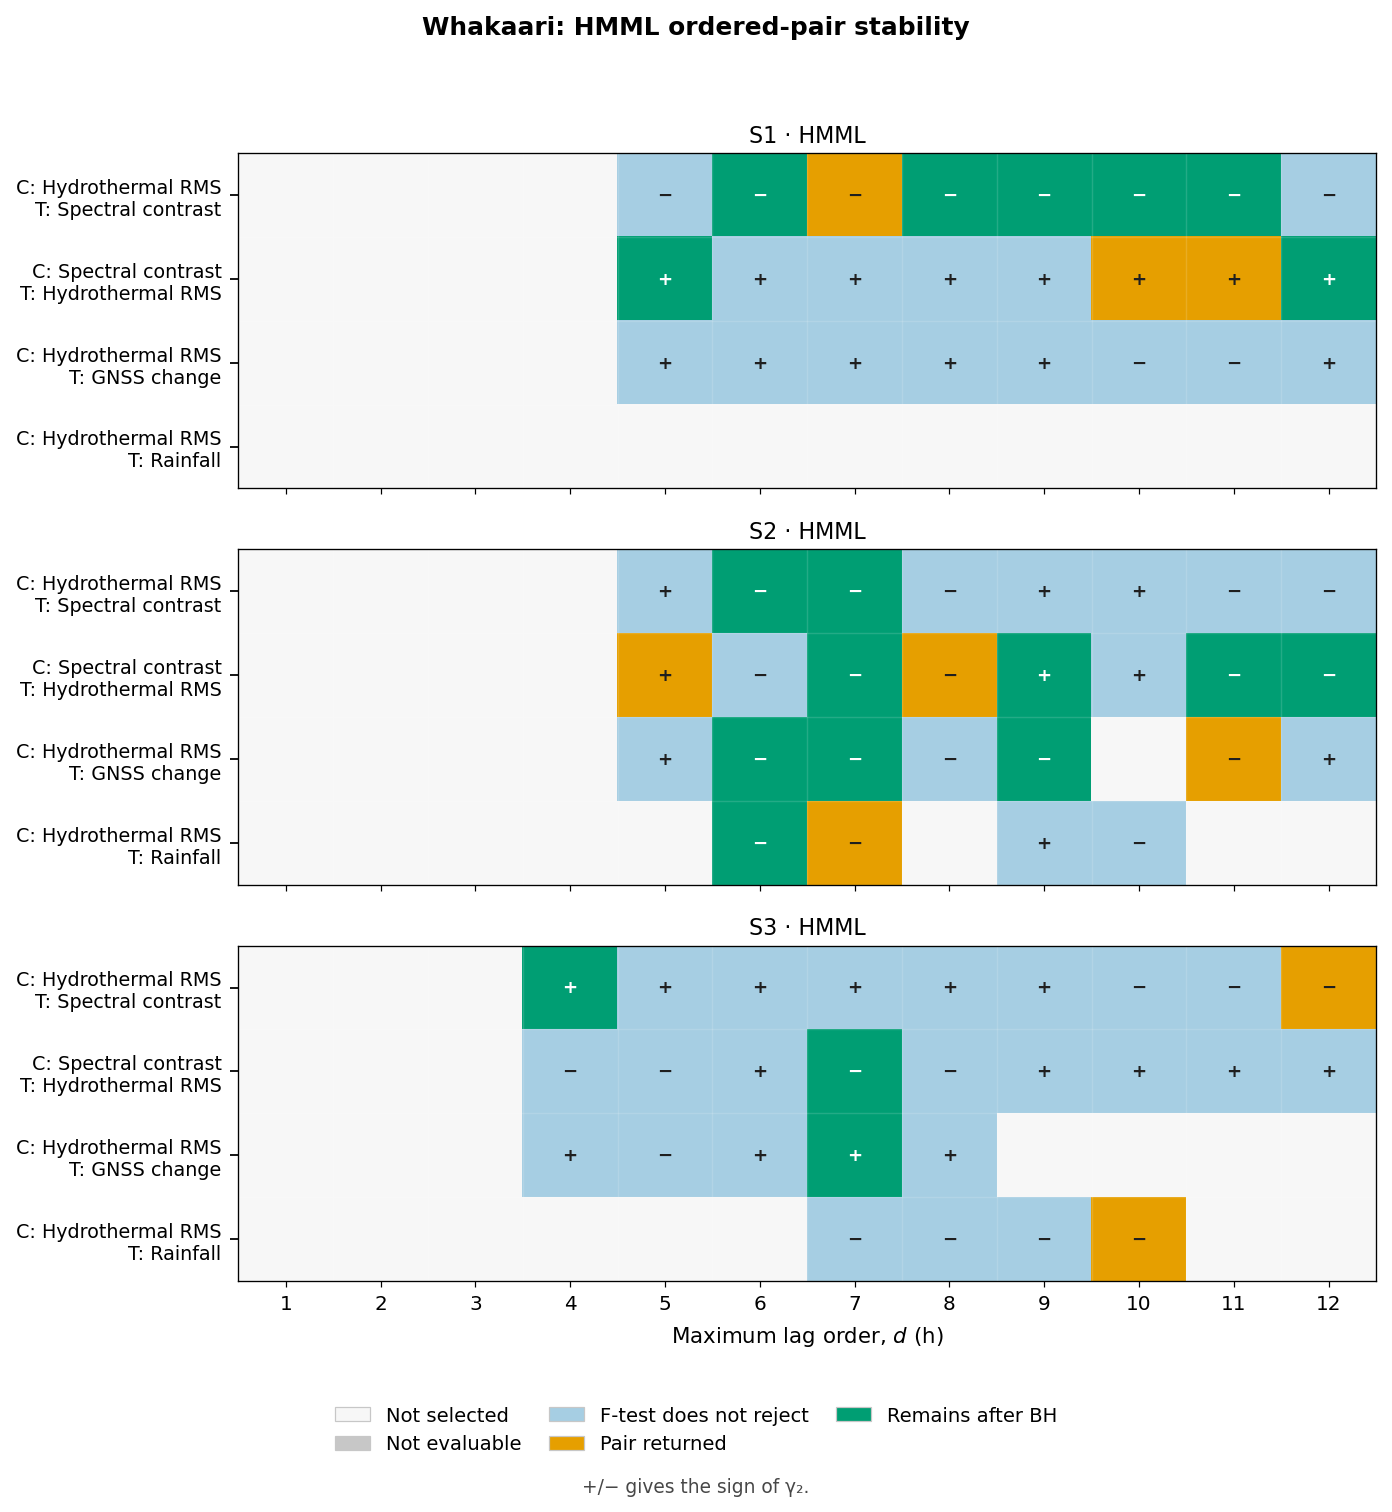

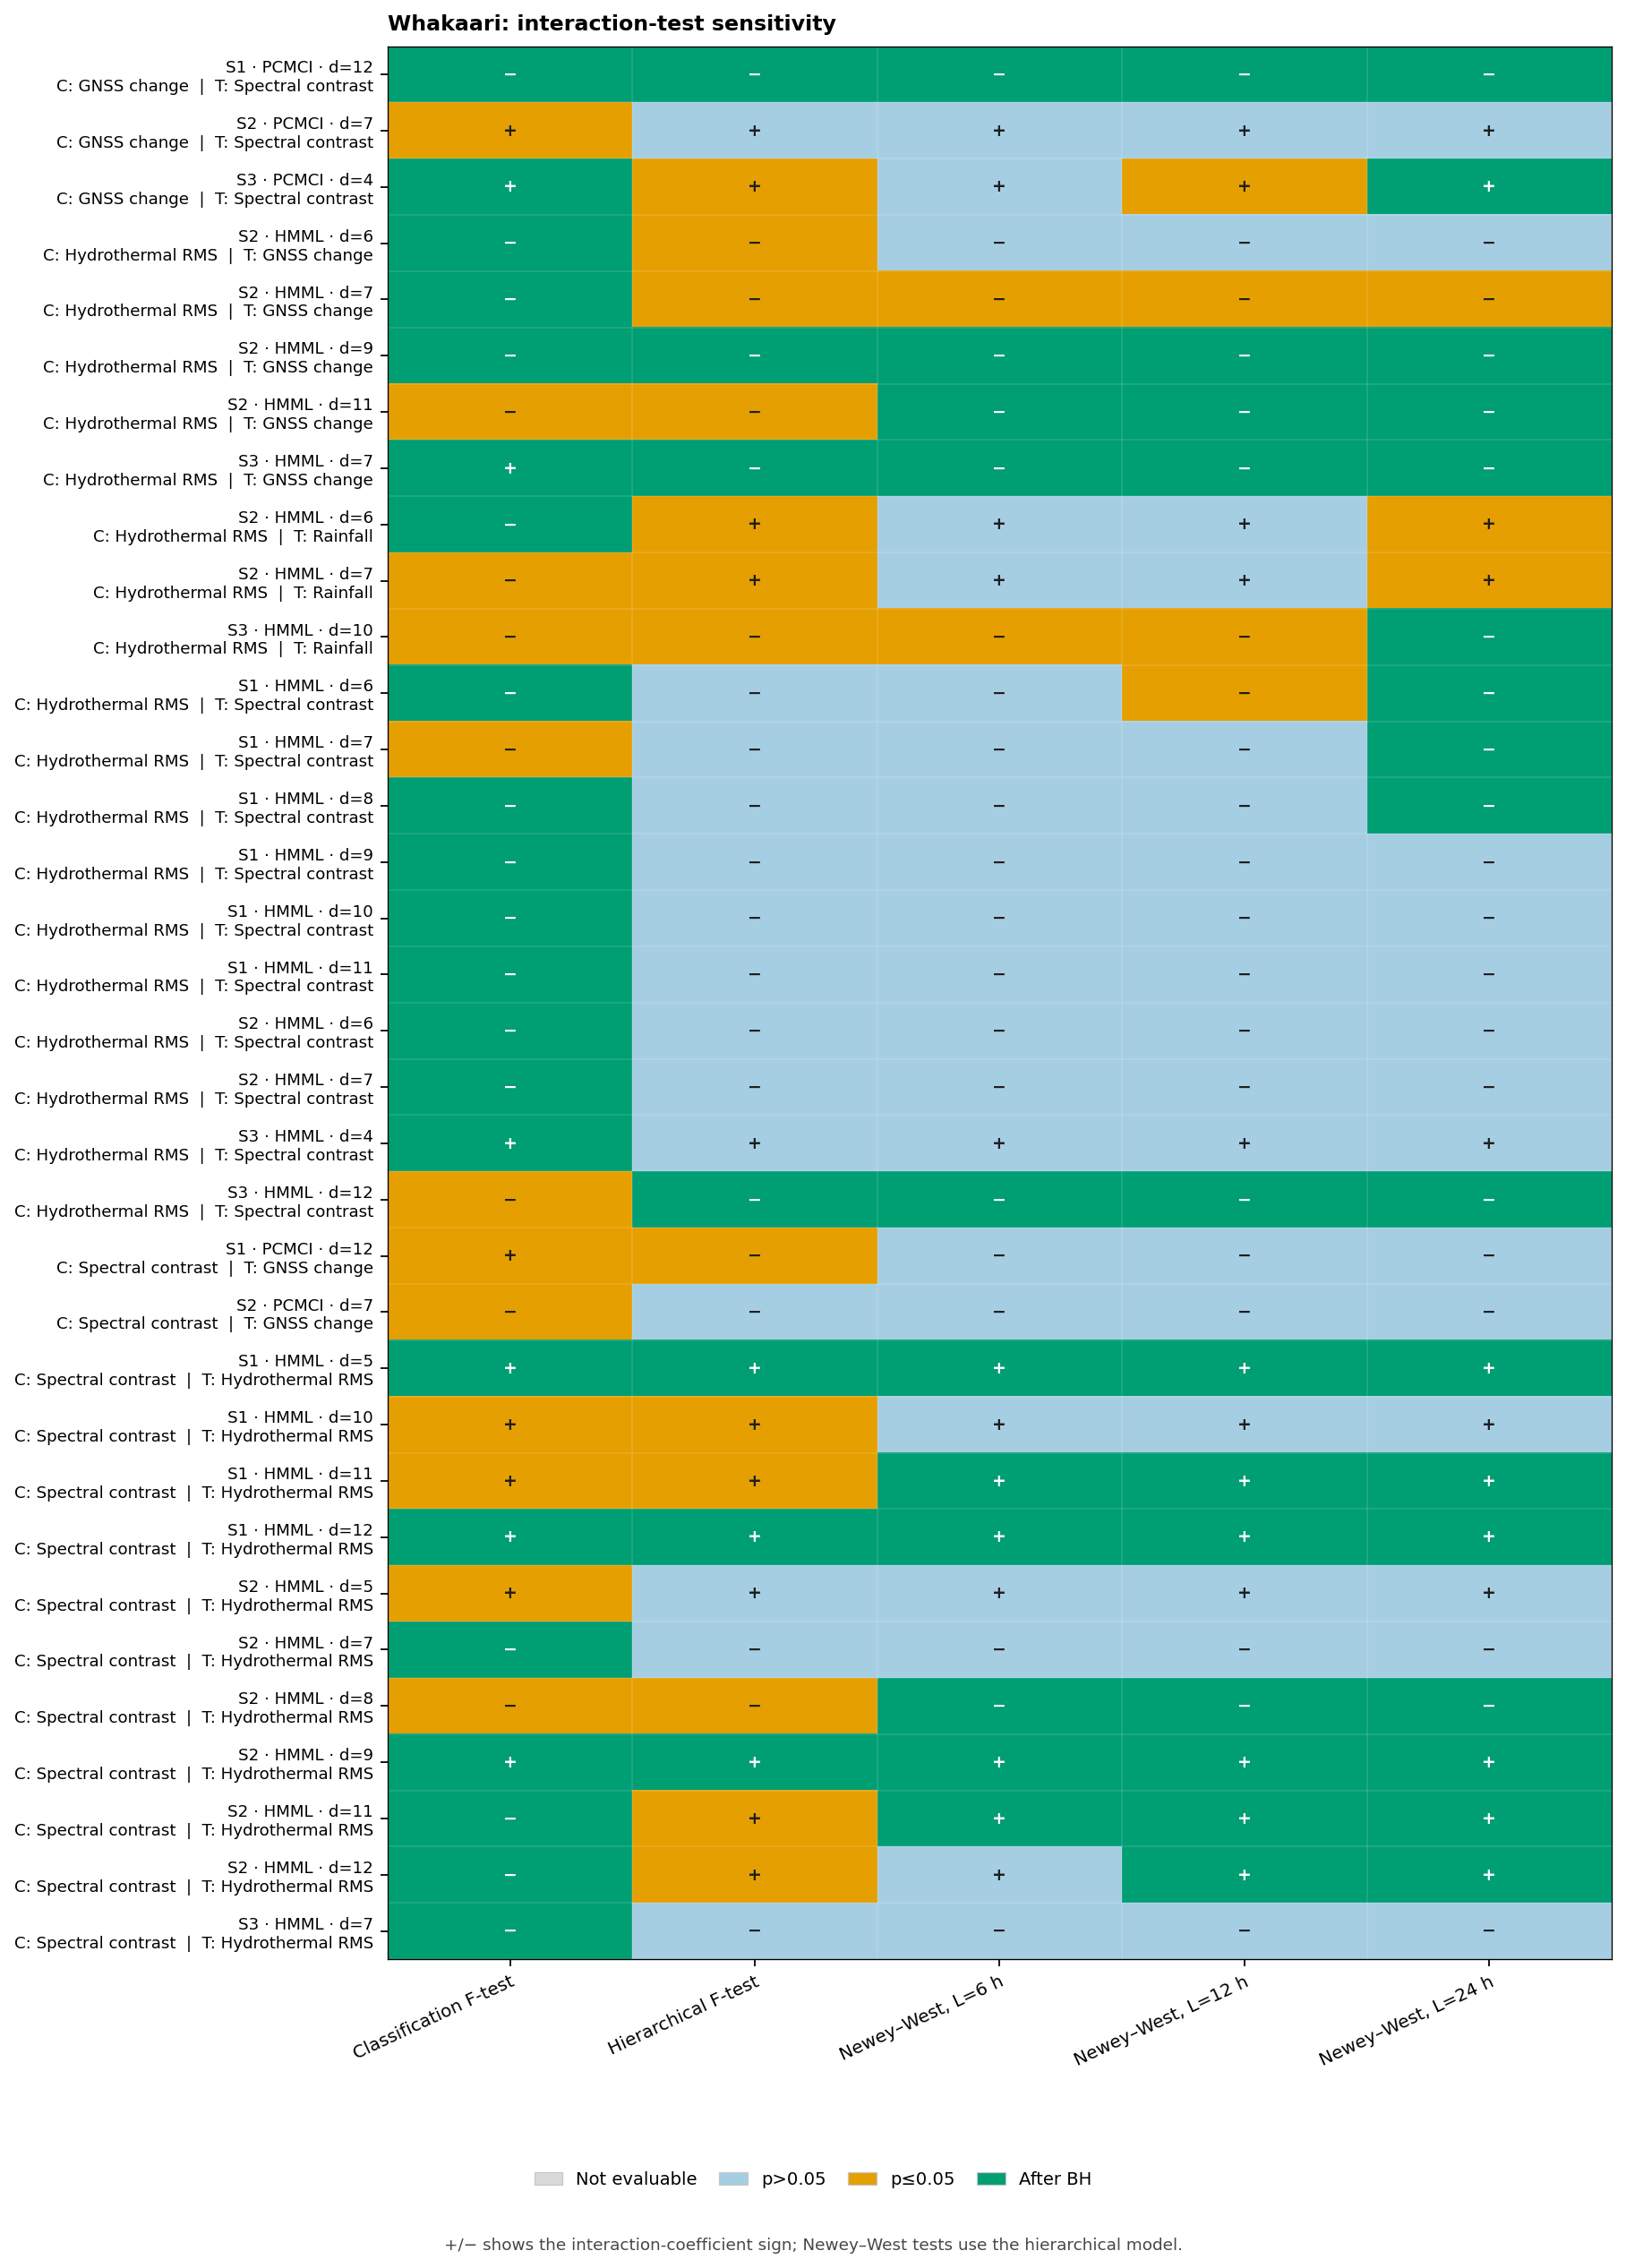

In [3]:
experiment_grid, all_diagnostics = run_unique_split_grid(
    analysis.X_model,
    analysis.X_decision,
    analysis.workflow_template,
    analysis.split_summary,
    run_one=run_one,
    run_specs=COMPACT_RUN_SPECS,
    lags=LAG_GRID,
    cond_ind_test=COND_IND_TEST,
    metadata={
        "case_pre_days": CASE_PRE_DAYS,
        "case_post_days": CASE_POST_DAYS,
        "reference_days": REFERENCE_DAYS,
        "alpha": ALPHA,
        "pcmci_pc_alpha": PCMCI_PC_ALPHA,
        "pcmci_plus_pc_alpha": PCMCI_PLUS_PC_ALPHA,
        "pcmci_alpha_level": PCMCI_ALPHA_LEVEL,
        "pcmci_fdr_method": PCMCI_FDR_METHOD,
        "conditional_independence_test": COND_IND_TEST,
        "newey_west_lags": NEWEY_WEST_LAGS,
    }
)

expected_rows = (
    len(analysis.unique_splits)
    * len(LAG_GRID)
    * len(COMPACT_RUN_SPECS)
)
if len(experiment_grid) != expected_rows:
    raise RuntimeError(
        f"Incomplete unique-partition grid: expected {expected_rows} rows, "
        f"received {len(experiment_grid)}."
    )

backend_summary = backend_split_summary(
    experiment_grid,
    lag_count=len(LAG_GRID),
    diagnostics=all_diagnostics,
)
pair_summary = pair_split_lag_summary(
    all_diagnostics,
    experiment_grid,
    lags=LAG_GRID,
    variable_labels=VARIABLE_LABELS,
)
warning_table = warning_summary(experiment_grid)
warning_pattern_table = warning_pattern_summary(
    experiment_grid,
    all_diagnostics,
)

show_table(backend_summary, "Backend behaviour within each unique partition")
show_table(pair_summary, "Returned pairs across partitions and lag orders")
show_table(
    bh_summary(all_diagnostics),
    "Classification F-tests before and after BH adjustment",
)
sensitivity_summary = interaction_sensitivity_summary(
    all_diagnostics,
    newey_west_lags=NEWEY_WEST_LAGS,
)
show_table(
    sensitivity_summary,
    "Interaction-test sensitivity",
)

if not warning_table.empty:
    show_table(warning_pattern_table, "Warning patterns by lag-order range")

hmml_grid = experiment_grid.loc[
    experiment_grid["backend"].eq("hmml")
].copy()

hmml_diagnostics = all_diagnostics.loc[
    all_diagnostics["backend"].eq("hmml")
].copy()

plot_pair_stability_heatmap(
    hmml_diagnostics,
    hmml_grid,
    lags=LAG_GRID,
    variable_labels=FIGURE_LABELS,
    backend_labels={"hmml": "HMML"},
    title="Whakaari: HMML ordered-pair stability",
    filename="whakaari_hmml_pair_stability_heatmap",
    save_dir=FIGURES_DIR,
)

plot_interaction_sensitivity_heatmap(
    all_diagnostics,
    newey_west_lags=NEWEY_WEST_LAGS,
    variable_labels=FIGURE_LABELS,
    title="Whakaari: interaction-test sensitivity",
    filename="whakaari_interaction_sensitivity",
    save_dir=FIGURES_DIR,
)

errors = experiment_grid.loc[experiment_grid["error"].notna()]
if not errors.empty:
    show_table(
        errors[["split_id", "backend", "lag", "error"]],
        "Execution errors",
    )

if SHOW_FULL_GRID:
    show_table(experiment_grid.drop(columns="error"), "Complete unique-partition grid")

## Automatic VAR lag-order choices

VAR-AIC and VAR-BIC are conventional automatic references. Their selected orders are already contained in the 1–12 grid; the first table reports the actual Cause–Trigger outcome at those orders. The second table extends only the information-criterion search to 18 and 24 h to determine whether the 12 h AIC choice is a search-boundary artefact; it does not extend the main Cause–Trigger grid.

In [4]:
automatic_lag_summary = automatic_lag_outcome_table(
    experiment_grid,
    all_diagnostics,
    analysis.lag_references,
    variable_labels=VARIABLE_LABELS,
)
show_table(
    automatic_lag_summary,
    "Cause–Trigger outcomes at VAR-AIC and VAR-BIC lag orders",
)

lag_sensitivity_frames = []
for maximum_lag in (12, 18, 24):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        current = reference_parameter_table(
            analysis.X_model,
            EFFECT,
            max_lags=maximum_lag,
        )
    current["warning"] = "; ".join(
        dict.fromkeys(str(item.message) for item in caught)
    )
    lag_sensitivity_frames.append(current)
lag_sensitivity_table = pd.concat(lag_sensitivity_frames, ignore_index=True)
show_table(
    lag_sensitivity_table.rename(columns={
        "criterion": "Criterion",
        "selected_lag": "Selected d (h)",
        "max_lags": "Maximum lag searched (h)",
        "search_boundary": "Search boundary",
        "warning": "Warning",
    })[[
        "Criterion",
        "Maximum lag searched (h)",
        "Selected d (h)",
        "Search boundary",
        "Warning",
    ]],
    "Whakaari VAR lag-order sensitivity (diagnostic only)",
)

Criterion,Selected d (h),Search boundary,Partition,Minimum I2 values,Backend,Outcome
AIC,12,True,S1,[72],HMML,Returned: Cause: Past-smoothed spectral contrast (4.5–8 / 8–16 Hz); trigger: Hydrothermal RMS (2–5 Hz) [Lagged]
AIC,12,True,S1,[72],PCMCI,Returned: Cause: Lagged GNSS deformation change; trigger: Past-smoothed spectral contrast (4.5–8 / 8–16 Hz) [Lagged]; Cause: Past-smoothed spectral contrast (4.5–8 / 8–16 Hz); trigger: Lagged GNSS deformation change [Lagged]
AIC,12,True,S1,[72],PCMCI+ with eligible exploratory τ=0 triggers,Trigger candidates found; F-test not evaluable
AIC,12,True,S2,[60],HMML,Returned: Cause: Past-smoothed spectral contrast (4.5–8 / 8–16 Hz); trigger: Hydrothermal RMS (2–5 Hz) [Lagged]
AIC,12,True,S2,[60],PCMCI,Trigger candidates found; F-test not evaluable
AIC,12,True,S2,[60],PCMCI+ with eligible exploratory τ=0 triggers,No lagged non-target B2 variables are available to construct V.
AIC,12,True,S3,"[36, 48]",HMML,Returned: Cause: Hydrothermal RMS (2–5 Hz); trigger: Past-smoothed spectral contrast (4.5–8 / 8–16 Hz) [Lagged]
AIC,12,True,S3,"[36, 48]",PCMCI,Trigger candidates found; F-test not evaluable
AIC,12,True,S3,"[36, 48]",PCMCI+ with eligible exploratory τ=0 triggers,No lagged non-target B2 variables are available to construct V.
BIC,2,False,S1,[72],HMML,No trigger candidates satisfy the mean condition.


Criterion,Maximum lag searched (h),Selected d (h),Search boundary,Warning
AIC,12,12,True,
BIC,12,2,False,
AIC,18,18,True,
BIC,18,2,False,
AIC,24,24,True,
BIC,24,2,False,


## Saved audit outputs

Three CSV files are written: one row per analysis run, one row per interaction test, and a consolidated summary. The interaction file contains the classification F-test, hierarchical F-test, Newey–West tests, and their separate BH adjustments.

In [5]:
if SAVE_RESULTS:
    saved_files = export_results_csvs(
        results_dir=RESULTS_DIR,
        case_prefix=CASE.name.lower(),
        experiment_grid=experiment_grid,
        diagnostics=all_diagnostics,
        design=analysis.design_summary,
        lag_references=analysis.lag_references,
        automatic_lag_summary=automatic_lag_summary,
        split_summary=analysis.split_summary,
        backend_summary=backend_summary,
        pair_summary=pair_summary,
        warning_table=warning_table,
        variable_labels=VARIABLE_LABELS,
        role_shift_table=role_shift_table,
        lag_sensitivity_table=lag_sensitivity_table,
        sensitivity_summary=sensitivity_summary,
    )
    show_table(saved_files, "Saved audit files")

File,Contents,Rows
whakaari_cause_trigger_all_runs.csv,"Every unique split × backend × maximum-lag-order run, including minimum-I2 values, candidate sets, returned pairs, warnings, stop reasons, and errors.",108
whakaari_cause_trigger_interaction_diagnostics.csv,"Every evaluated cause-trigger combination, the classification F-test, the hierarchical F-test, Newey–West tests, and separate case-wide BH adjustments.",118
whakaari_cause_trigger_summary.csv,"Design, split stability, automatic AIC/BIC outcomes, backend behaviour, pair recurrence, mean-shift scores, warnings, BH-adjusted results, interaction sensitivity, and any lag-order sensitivity check.",83
